In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import smarts_cerebellum.globals as gl

In [2]:
# all regions minus vermis bc anti-vermis club!
"""
array(['M1L', 'M2L', 'M3L', 'M4L', 'A1L', 'A2L', 'A3L', 'D1L', 'D2L',
       'D3L', 'D4L', 'S1L', 'S2L', 'S3L', 'S4L', 'S5L', 'M1R', 'M2R',
       'M3R', 'M4R', 'A1R', 'A2R', 'A3R', 'D1R', 'D2R', 'D3R', 'D4R',
       'S1R', 'S2R', 'S3R', 'S4R', 'S5R'], dtype=object)
"""

"\narray(['M1L', 'M2L', 'M3L', 'M4L', 'A1L', 'A2L', 'A3L', 'D1L', 'D2L',\n       'D3L', 'D4L', 'S1L', 'S2L', 'S3L', 'S4L', 'S5L', 'M1R', 'M2R',\n       'M3R', 'M4R', 'A1R', 'A2R', 'A3R', 'D1R', 'D2R', 'D3R', 'D4R',\n       'S1R', 'S2R', 'S3R', 'S4R', 'S5R'], dtype=object)\n"

In [3]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']

reds = sns.color_palette("Reds", n_colors=len(regions)//2+1)
blues = sns.color_palette("Blues", n_colors=len(regions)//2+1)


## Modulated GM volume

convergence warnings

In [4]:
# currently avaialble: 'GM_mod', 'T1'
segment = 'GM'

# observed means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')

# estimated means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')

# specify regions
patients_lme = patients_lme[patients_lme.regionname.isin(regions)]
controls_lme = controls_lme[controls_lme.regionname.isin(regions)]
patients_actual = patients_actual[patients_actual.regionname.isin(regions)]
controls_actual = controls_actual[controls_actual.regionname.isin(regions)]

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[2]
controls_lme['hemisphere'] = controls_lme.regionname.str[2]
patients_actual['hemisphere'] = patients_actual.regionname.str[2]
controls_actual['hemisphere'] = controls_actual.regionname.str[2]


left_patients_lme = patients_lme[patients_lme.hemisphere == 'L'].sort_values('Week')
left_patients_actual = patients_actual[patients_actual.hemisphere == 'L'].sort_values('Week')
left_controls_lme = controls_lme[controls_lme.hemisphere == 'L'].sort_values('Week')
left_controls_actual = controls_actual[controls_actual.hemisphere == 'L'].sort_values('Week')

right_patients_lme = patients_lme[patients_lme.hemisphere == 'R'].sort_values('Week')
right_patients_actual = patients_actual[patients_actual.hemisphere == 'R'].sort_values('Week')
right_controls_lme = controls_lme[controls_lme.hemisphere == 'R'].sort_values('Week')
right_controls_actual = controls_actual[controls_actual.hemisphere == 'R'].sort_values('Week')

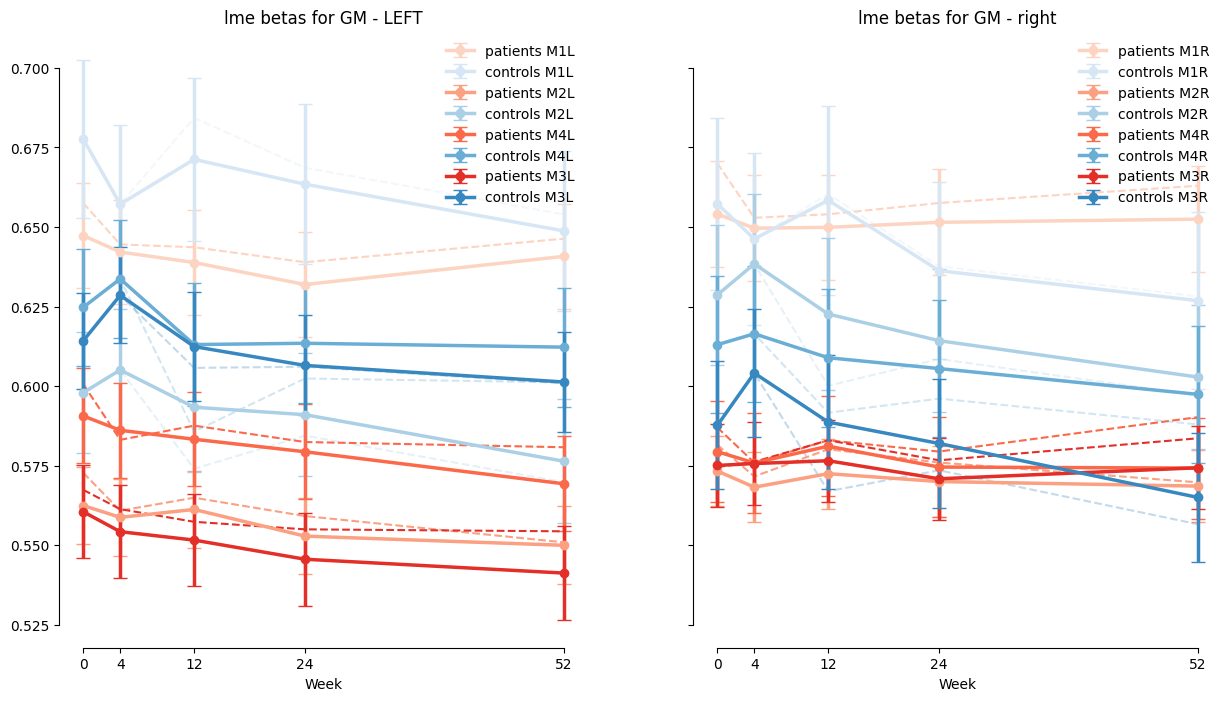

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15,8), sharey = True)

# left hemisphere

for idx, region in enumerate(left_patients_lme.regionname.unique()):

    plot_left_patients_lme = left_patients_lme[left_patients_lme.regionname == region]
    plot_left_patients_actual = left_patients_actual[left_patients_actual.regionname == region]
    plot_left_controls_lme = left_controls_lme[left_controls_lme.regionname == region]
    plot_left_controls_actual = left_controls_actual[left_controls_actual.regionname == region]

    ax[0].errorbar(x = plot_left_patients_lme.Week, y = plot_left_patients_lme.beta, yerr = plot_left_patients_lme.se, color = reds[idx], label = f'patients {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5)
    ax[0].plot(plot_left_patients_actual.Week, plot_left_patients_actual['mean'], color = reds[idx], linestyle = '--')
    ax[0].errorbar(x = plot_left_controls_lme.Week, y = plot_left_controls_lme.beta, yerr = plot_left_controls_lme.se, color = blues[idx], label = f'controls {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 1)
    ax[0].plot(plot_left_controls_actual.Week, plot_left_controls_actual['mean'], color = blues[idx], linestyle = '--', alpha = 0.3)

ax[0].set_title(f'lme betas for {segment} - LEFT')
ax[0].legend(bbox_to_anchor = (1,1), loc = 'upper right', frameon = False)

# right hemisphere

for idx, region in enumerate(right_patients_lme.regionname.unique()):

    plot_right_patients_lme = right_patients_lme[right_patients_lme.regionname == region]
    plot_right_patients_actual = right_patients_actual[right_patients_actual.regionname == region]
    plot_right_controls_lme = right_controls_lme[right_controls_lme.regionname == region]
    plot_right_controls_actual = right_controls_actual[right_controls_actual.regionname == region]

    ax[1].errorbar(x = plot_right_patients_lme.Week, y = plot_right_patients_lme.beta, yerr = plot_right_patients_lme.se, color = reds[idx], label = f'patients {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5)
    ax[1].plot(plot_right_patients_actual.Week, plot_right_patients_actual['mean'], color = reds[idx], linestyle = '--')
    ax[1].errorbar(x = plot_right_controls_lme.Week, y = plot_right_controls_lme.beta, yerr = plot_right_controls_lme.se, color = blues[idx], label = f'controls {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 1)
    ax[1].plot(plot_right_controls_actual.Week, plot_right_controls_actual['mean'], color = blues[idx], linestyle = '--', alpha = 0.3)

ax[1].set_title(f'lme betas for {segment} - right')
ax[1].legend(bbox_to_anchor = (1,1), loc = 'upper right', frameon = False)

weeks = [0, 4, 12, 24, 52]
for i in range(2):
    ax[i].set_xticks(weeks)
    ax[i].set_xlabel("Week")
    

sns.despine(trim = True)
plt.show()
    


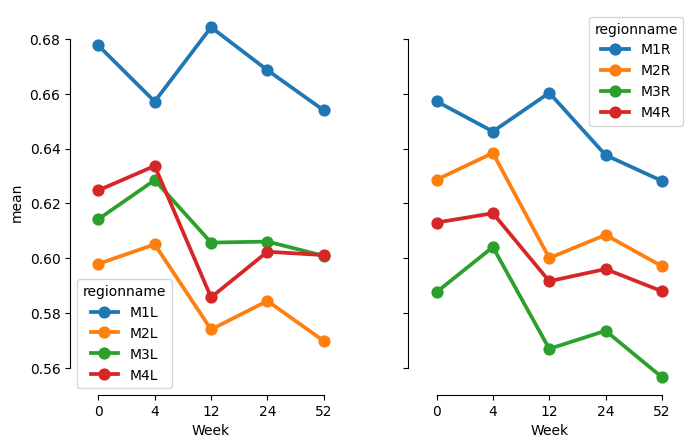

In [6]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)
sns.pointplot(data = left_controls_actual, x = 'Week', y = 'mean', hue = 'regionname', ax = ax[0])
sns.pointplot(data = right_controls_actual, x = 'Week', y = 'mean', hue = 'regionname', ax = ax[1])

sns.despine(trim = True)
plt.show()

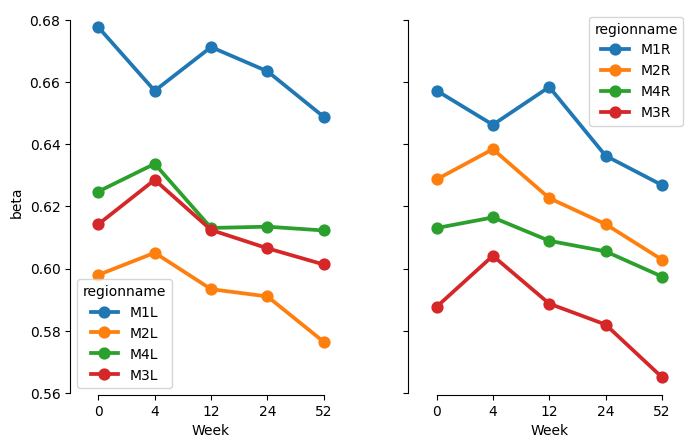

In [7]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)
sns.pointplot(data = left_controls_lme, x = 'Week', y = 'beta', hue = 'regionname', ax = ax[0])
sns.pointplot(data = right_controls_lme, x = 'Week', y = 'beta', hue = 'regionname', ax = ax[1])

sns.despine(trim = True)
plt.show()

## T1

In [8]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'T1'

# observed means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Nettekoven_2024_{segment}_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Nettekoven_2024_{segment}_mean.tsv'), sep = '\t')

# estimated means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_Nettekoven_2024_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_Nettekoven_2024_lme.tsv'), sep = '\t')


# specify regions
patients_lme = patients_lme[patients_lme.regionname.isin(regions)]
controls_lme = controls_lme[controls_lme.regionname.isin(regions)]
patients_actual = patients_actual[patients_actual.regionname.isin(regions)]
controls_actual = controls_actual[controls_actual.regionname.isin(regions)]

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[2]
controls_lme['hemisphere'] = controls_lme.regionname.str[2]
patients_actual['hemisphere'] = patients_actual.regionname.str[2]
controls_actual['hemisphere'] = controls_actual.regionname.str[2]


left_patients_lme = patients_lme[patients_lme.hemisphere == 'L'].sort_values('Week')
left_patients_actual = patients_actual[patients_actual.hemisphere == 'L'].sort_values('Week')
left_controls_lme = controls_lme[controls_lme.hemisphere == 'L'].sort_values('Week')
left_controls_actual = controls_actual[controls_actual.hemisphere == 'L'].sort_values('Week')

right_patients_lme = patients_lme[patients_lme.hemisphere == 'R'].sort_values('Week')
right_patients_actual = patients_actual[patients_actual.hemisphere == 'R'].sort_values('Week')
right_controls_lme = controls_lme[controls_lme.hemisphere == 'R'].sort_values('Week')
right_controls_actual = controls_actual[controls_actual.hemisphere == 'R'].sort_values('Week')

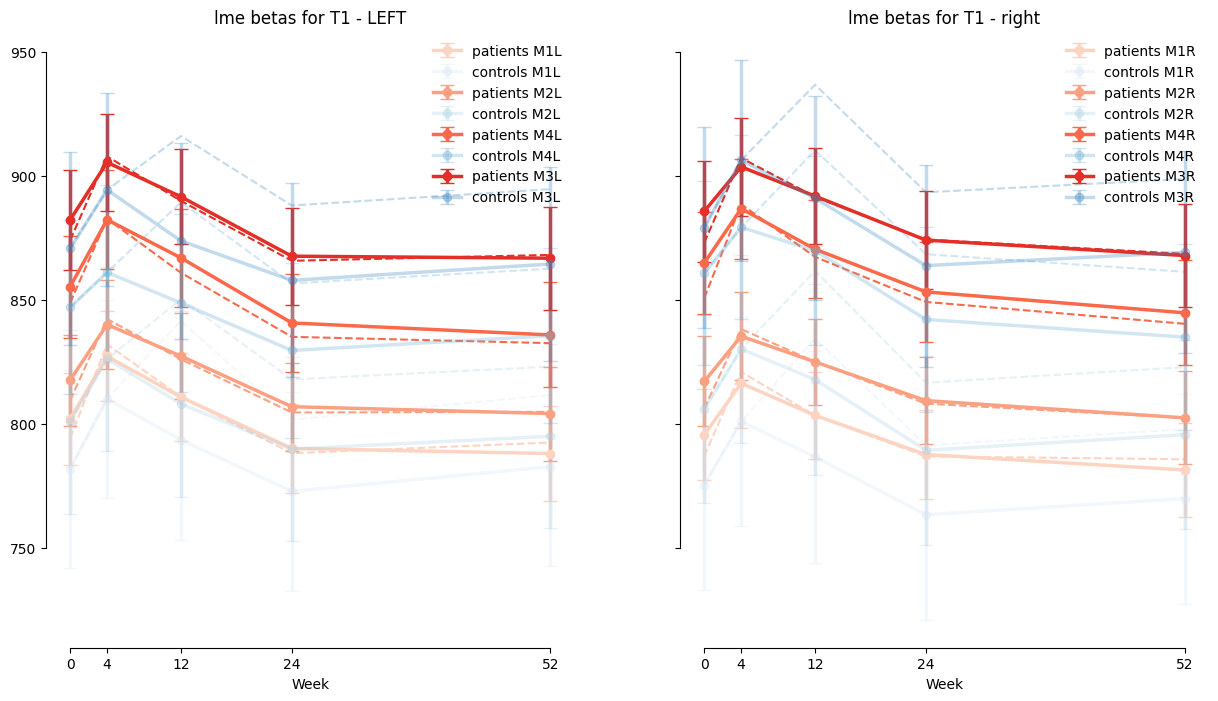

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15,8), sharey = True)

# left hemisphere

for idx, region in enumerate(left_patients_lme.regionname.unique()):

    plot_left_patients_lme = left_patients_lme[left_patients_lme.regionname == region]
    plot_left_patients_actual = left_patients_actual[left_patients_actual.regionname == region]
    plot_left_controls_lme = left_controls_lme[left_controls_lme.regionname == region]
    plot_left_controls_actual = left_controls_actual[left_controls_actual.regionname == region]

    ax[0].errorbar(x = plot_left_patients_lme.Week, y = plot_left_patients_lme.beta, yerr = plot_left_patients_lme.se, color = reds[idx], label = f'patients {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5)
    ax[0].plot(plot_left_patients_actual.Week, plot_left_patients_actual['mean'], color = reds[idx], linestyle = '--')
    ax[0].errorbar(x = plot_left_controls_lme.Week, y = plot_left_controls_lme.beta, yerr = plot_left_controls_lme.se, color = blues[idx], label = f'controls {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 0.3)
    ax[0].plot(plot_left_controls_actual.Week, plot_left_controls_actual['mean'], color = blues[idx], linestyle = '--', alpha = 0.3)

ax[0].set_title(f'lme betas for {segment} - LEFT')
ax[0].legend(bbox_to_anchor = (1,1), loc = 'upper right', frameon = False)

# right hemisphere

for idx, region in enumerate(right_patients_lme.regionname.unique()):

    plot_right_patients_lme = right_patients_lme[right_patients_lme.regionname == region]
    plot_right_patients_actual = right_patients_actual[right_patients_actual.regionname == region]
    plot_right_controls_lme = right_controls_lme[right_controls_lme.regionname == region]
    plot_right_controls_actual = right_controls_actual[right_controls_actual.regionname == region]

    ax[1].errorbar(x = plot_right_patients_lme.Week, y = plot_right_patients_lme.beta, yerr = plot_right_patients_lme.se, color = reds[idx], label = f'patients {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5)
    ax[1].plot(plot_right_patients_actual.Week, plot_right_patients_actual['mean'], color = reds[idx], linestyle = '--')
    ax[1].errorbar(x = plot_right_controls_lme.Week, y = plot_right_controls_lme.beta, yerr = plot_right_controls_lme.se, color = blues[idx], label = f'controls {region}',
                   fmt = '-o', capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 0.3)
    ax[1].plot(plot_right_controls_actual.Week, plot_right_controls_actual['mean'], color = blues[idx], linestyle = '--', alpha = 0.3)

ax[1].set_title(f'lme betas for {segment} - right')
ax[1].legend(bbox_to_anchor = (1,1), loc = 'upper right', frameon = False)

weeks = [0, 4, 12, 24, 52]
for i in range(2):
    ax[i].set_xticks(weeks)
    ax[i].set_xlabel("Week")
    

sns.despine(trim = True)
plt.show()
    


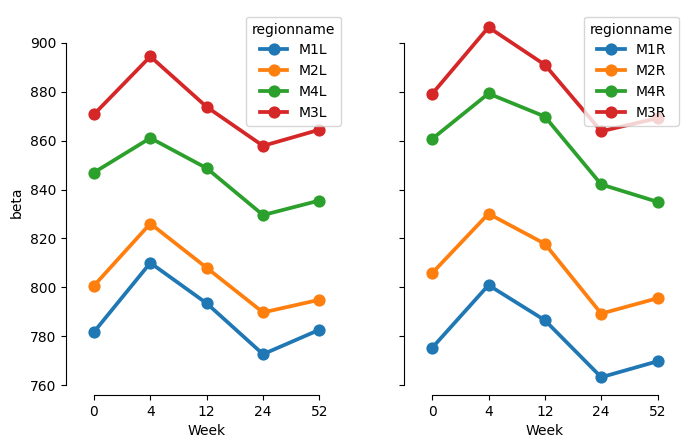

In [10]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)
sns.pointplot(data = left_controls_lme, x = 'Week', y = 'beta', hue = 'regionname', ax = ax[0])
sns.pointplot(data = right_controls_lme, x = 'Week', y = 'beta', hue = 'regionname', ax = ax[1])

sns.despine(trim = True)
plt.show()

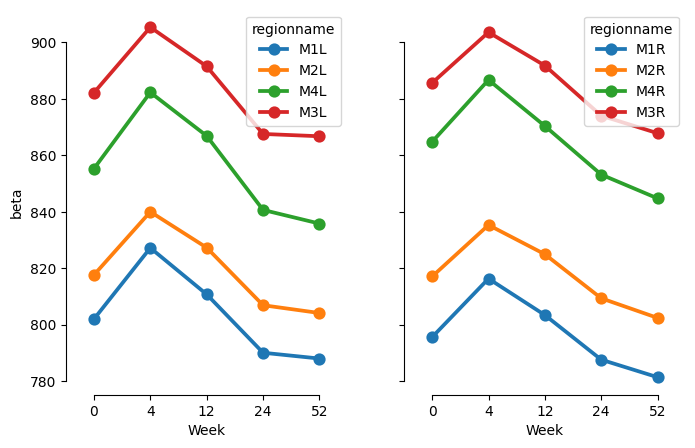

In [11]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)
sns.pointplot(data = left_patients_lme, x = 'Week', y = 'beta', hue = 'regionname', ax = ax[0])
sns.pointplot(data = right_patients_lme, x = 'Week', y = 'beta', hue = 'regionname', ax = ax[1])

sns.despine(trim = True)
plt.show()